#DATA LOADING AND CLEANING IT

In [2]:
import pandas as pd
from h11 import PRODUCT_ID

df = pd.read_csv(r"C:\Users\Rushabh\Downloads\ai4i2020.csv")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)


In [3]:
print(df.head())
print(100 *"#")
print(f"The Shape of Datasets: {df.shape}")
print(100 *"#")
df["Machine failure"].value_counts(normalize=True) * 100

df["Product ID"].nunique()
df["Type"].value_counts()

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF
0    1     M14860    M                298.1                    308.6                    1551         42.8                0                0    0    0    0    0    0
1    2     L47181    L                298.2                    308.7                    1408         46.3                3                0    0    0    0    0    0
2    3     L47182    L                298.1                    308.5                    1498         49.4                5                0    0    0    0    0    0
3    4     L47183    L                298.2                    308.6                    1433         39.5                7                0    0    0    0    0    0
4    5     L47184    L                298.2                    308.7                    1408         40.0                9                0    0    0    0    0    0
##########

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [4]:
pd.crosstab(df["Machine failure"], df["Type"])


Type,H,L,M
Machine failure,,,
0,982,5765,2914
1,21,235,83


In [5]:
df["Product ID"].nunique()
df["Product ID"].value_counts().value_counts()
df["Product ID"].describe()

count      10000
unique     10000
top       M14860
freq           1
Name: Product ID, dtype: object

In [6]:
df[["TWF", "HDF", "PWF", "OSF", "RNF"]].apply(pd.Series.value_counts)

,TWF,HDF,PWF,OSF,RNF
0,9954,9885,9905,9902,9981
1,46,115,95,98,19


In [7]:
pd.crosstab(df["TWF"], df["Machine failure"])

Machine failure,0,1
TWF,,
0,9661,293
1,0,46


-->TWF is strongly associated with Machine failure. All 46 observations with TWF = 1 also have Machine failure = 1, indicating that TWF may represent a failure indicator rather than a pre-failure predictive feature.

In [8]:
pd.crosstab(df["OSF"], df["Machine failure"])

Machine failure,0,1
OSF,,
0,9661,241
1,0,98


In [9]:
pd.crosstab(df["RNF"], df["Machine failure"])


Machine failure,0,1
RNF,,
0,9643,338
1,18,1


In [10]:
pd.crosstab(df["HDF"], df["Machine failure"])

Machine failure,0,1
HDF,,
0,9661,224
1,0,115


In [11]:
pd.crosstab(df["PWF"], df["Machine failure"])


Machine failure,0,1
PWF,,
0,9661,244
1,0,95


In [12]:
pd.crosstab(
    df["RNF"],
    df["Machine failure"],
)

Machine failure,0,1
RNF,,
0,9643,338
1,18,1


In [13]:
df[df["RNF"] == 1]


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,1447,50.4,140,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,1687,27.7,95,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,1602,32.3,2,0,0,0,0,0,1
3611,3612,L50791,L,301.7,310.9,1405,46.4,207,1,1,0,0,0,1
5471,5472,L52651,L,302.7,312.3,1346,61.2,170,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,1499,35.0,215,0,0,0,0,0,1


In [14]:
df.groupby("RNF")[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
RNF,,,,,
0,300.003386,310.004118,1538.878469,39.979892,107.919547
1,300.815789,310.763158,1485.000000,43.673684,124.473684


In [15]:
pd.crosstab(df["RNF"], df["Type"])

Type,H,L,M
RNF,,,
0,999,5987,2995
1,4,13,2


In [16]:
df[(df["RNF"] == 1) & (df["Machine failure"] == 1)]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
3611,3612,L50791,L,301.7,310.9,1405,46.4,207,1,1,0,0,0,1


In [17]:
df[df["RNF"] == 1][
    ["Type",
     "Air temperature [K]",
     "Process temperature [K]",
     "Rotational speed [rpm]",
     "Torque [Nm]",
     "Tool wear [min]",
     "Machine failure",
     "TWF", "HDF", "PWF", "OSF", "RNF"]
]

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,M,297.0,308.3,1399,46.4,132,0,0,0,0,0,1
1302,L,298.6,309.8,1505,45.7,144,0,0,0,0,0,1
1748,H,298.4,307.7,1626,31.1,166,0,0,0,0,0,1
2072,L,299.6,309.5,1570,35.5,189,0,0,0,0,0,1
2559,L,299.3,309.0,1447,50.4,140,0,0,0,0,0,1
3065,M,300.1,309.2,1687,27.7,95,0,0,0,0,0,1
3452,H,301.6,310.5,1602,32.3,2,0,0,0,0,0,1
3611,L,301.7,310.9,1405,46.4,207,1,1,0,0,0,1
5471,L,302.7,312.3,1346,61.2,170,0,0,0,0,0,1
5489,L,302.6,312.1,1499,35.0,215,0,0,0,0,0,1


In [18]:
df[df["RNF"] == 1]["Tool wear [min]"].describe()

count     19.000000
mean     124.473684
std       69.550436
min        2.000000
25%       71.500000
50%      144.000000
75%      176.000000
max      215.000000
Name: Tool wear [min], dtype: float64

In [19]:
df[df["RNF"] == 0]["Tool wear [min]"].describe()

count    9981.000000
mean      107.919547
std        63.642117
min         0.000000
25%        53.000000
50%       108.000000
75%       162.000000
max       253.000000
Name: Tool wear [min], dtype: float64

In [20]:
df.groupby("RNF")["Tool wear [min]"].describe()

,count,mean,std,min,25%,50%,75%,max
RNF,,,,,,,,
0,9981.0,107.919547,63.642117,0.0,53.0,108.0,162.0,253.0
1,19.0,124.473684,69.550436,2.0,71.5,144.0,176.0,215.0


In [21]:
pd.crosstab(df["Type"], df["RNF"])

RNF,0,1
Type,,
H,999,4
L,5987,13
M,2995,2


# DROPPING COLS
(UDI,Product ID,TWF,HDF,PWF,OSF,RNF)
WE ARE DROPPING TWF HDF PWF OSF AND RNF DUE TO TARGET LEAKAGE
TARGET LEAKAGE:Target leakage happens when information that is directly related to, derived from, or only available after the target outcome is included as an input feature to the ML model.

In [22]:
df.drop(
    columns=[
        'UDI',
        'Product ID',
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'
    ],
    inplace=True
)

In [23]:
df.head()
df.shape

(10000, 7)

In [24]:
df.isnull().sum()


Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.dtypes

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object

In [27]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


   #1.WE HAVE ZERO NULL VALUES
   #2.WE FOUND DUPLICATES ZERO
   #3.INVALID OBVIOUS DATA NOT FOUND
   #4.LEAKAGE FEATURE REMOVED

<Axes: xlabel='Machine failure'>

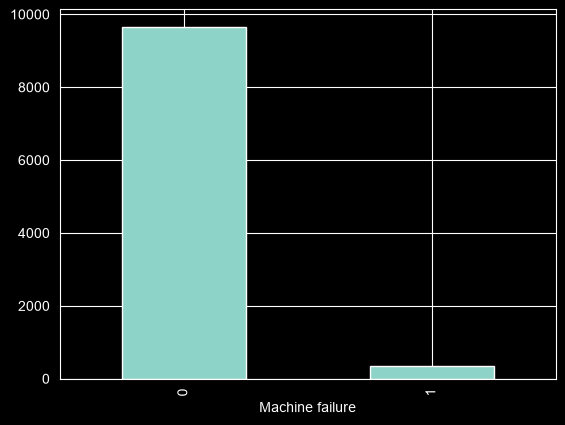

In [28]:
df["Machine failure"].value_counts().plot(kind="bar")

The target variable is highly imbalanced, with non-failure observations representing 96.61% of the dataset and failure observations representing only 3.39%. Therefore, accuracy alone should not be relied upon for model evaluation.

<Axes: >

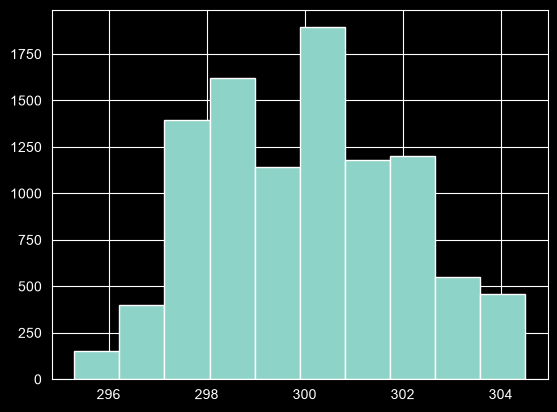

In [29]:
df["Air temperature [K]"].hist()

Takes continuous air-temperature values and divides them into 5 ranges.
Your air temperature goes from about 295.3 K to 304.5 K, so Pandas creates 5 intervals covering that range.

groupby("Air Temp Bin")
Groups all machines according to their temperature range.
["Machine failure"]
We're interested only in the target column.

<Axes: xlabel='Air Temp Bin'>

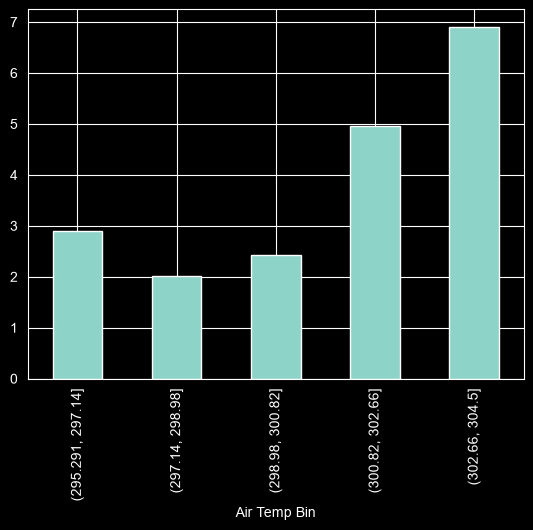

In [30]:
df["Air Temp Bin"] = pd.cut(
    df["Air temperature [K]"],
    bins=5
)

failure_rate = (
    df.groupby("Air Temp Bin", observed=True)["Machine failure"]
      .mean() * 100
)

failure_rate.plot(kind="bar")

<Axes: >

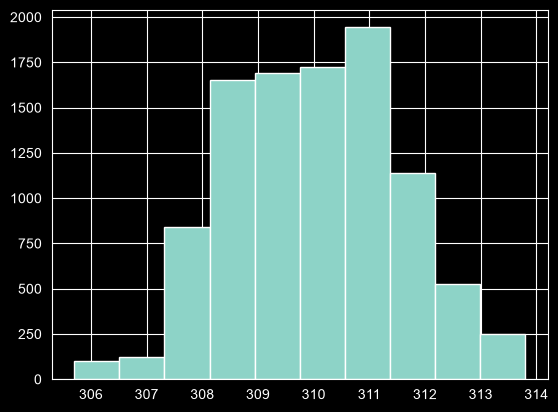

In [31]:
df["Process temperature [K]"].hist()


<Axes: xlabel='Process Temp Bin'>

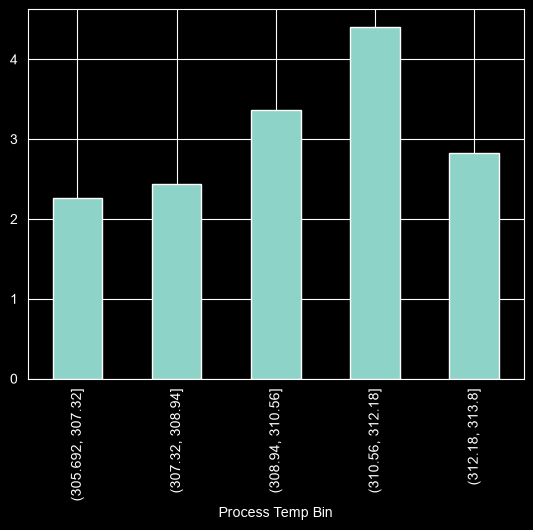

In [32]:
df["Process Temp Bin"] = pd.cut(
    df["Process temperature [K]"],
    bins = 5
)
failure_rate =df.groupby("Process Temp Bin",observed = True)["Machine failure"] .mean() * 100
failure_rate.plot(kind="bar")

Process Temperature: Machine failures are more concentrated in the 310–312 K range, indicating a potential relationship between process temperature and machine failure.

<Axes: >

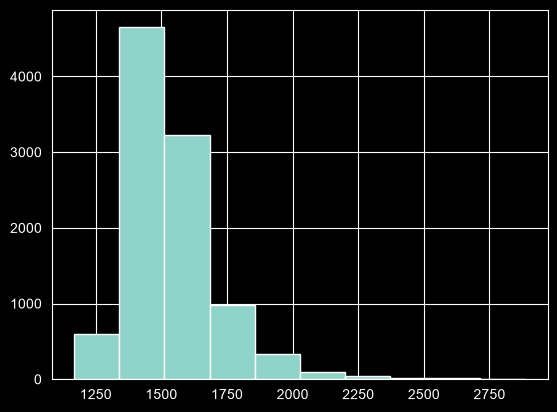

In [33]:
df["Rotational speed [rpm]"].hist()



<Axes: xlabel='Rotational speed Bin'>

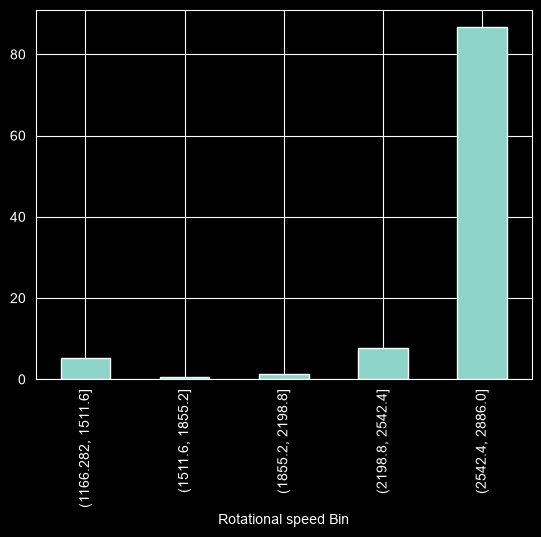

In [34]:
df["Rotational speed Bin"] = pd.cut(
    df["Rotational speed [rpm]"],
    bins = 5,
)
failure_rate = df.groupby("Rotational speed Bin",observed = True)["Machine failure"] .mean() * 100
failure_rate.plot(kind="bar")

<Axes: >

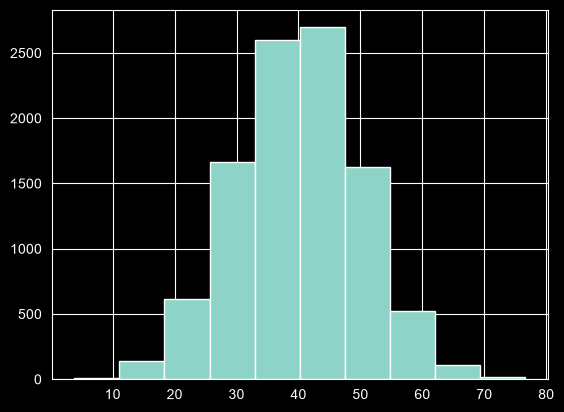

In [35]:
df["Torque [Nm]"].hist()


<Axes: xlabel='Torque Bin'>

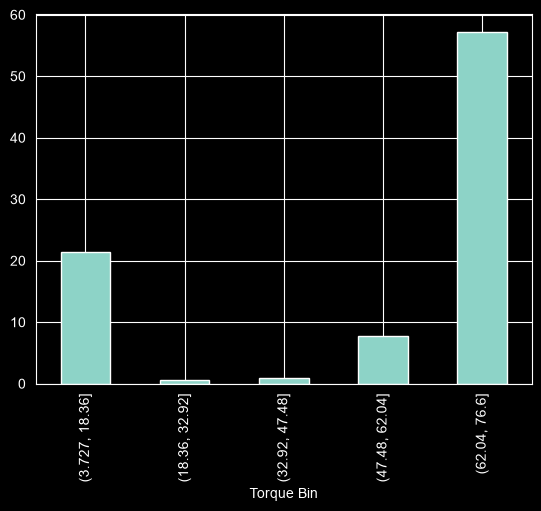

In [36]:
df["Torque Bin"] = pd.cut(
    df["Torque [Nm]"],
    bins = 5
)
failure_rate = df.groupby("Torque Bin",observed = True)["Machine failure"] .mean() * 100
failure_rate.plot(kind = "bar")

Torque: The 62.04–76.6 Nm range shows the highest observed machine-failure rate, suggesting that higher torque levels may be associated with increased failure risk in this dataset.

<Axes: >

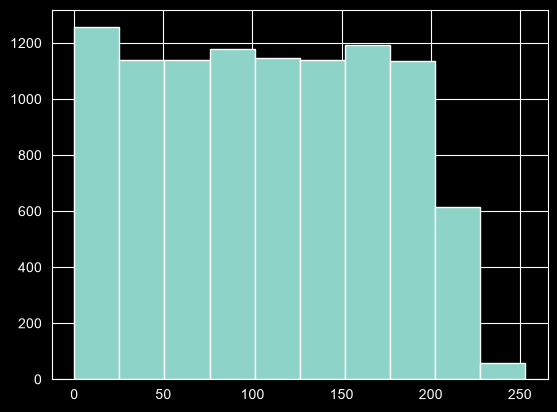

In [37]:
df["Tool wear [min]"].hist()

<Axes: xlabel='Tool wear bin'>

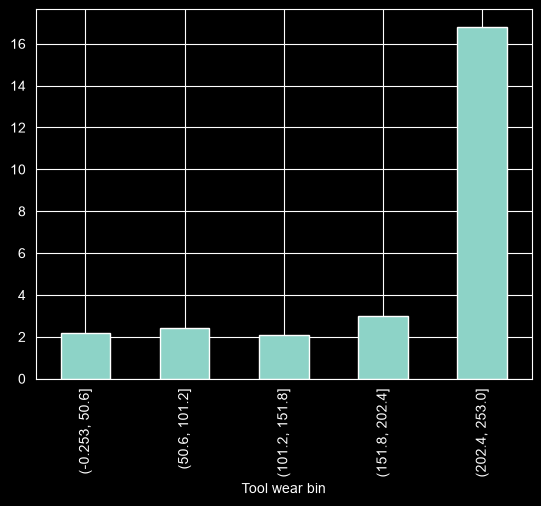

In [38]:
df["Tool wear bin"] = pd.cut(
    df["Tool wear [min]"],
    bins = 5
)
failure_rate = df.groupby("Tool wear bin",observed = True)["Machine failure"] .mean() * 100
failure_rate.plot(kind="bar")

The highest tool-wear range (202–253 min) shows a substantially higher observed machine-failure rate than the lower wear ranges, suggesting that high tool wear is strongly associated with machine failure.

<Axes: >

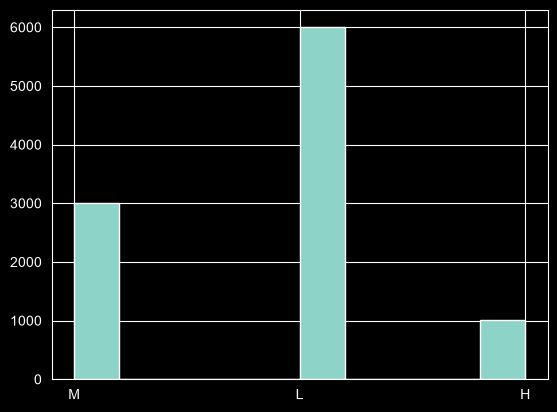

In [39]:
df["Type"].hist()

<Axes: xlabel='Type'>

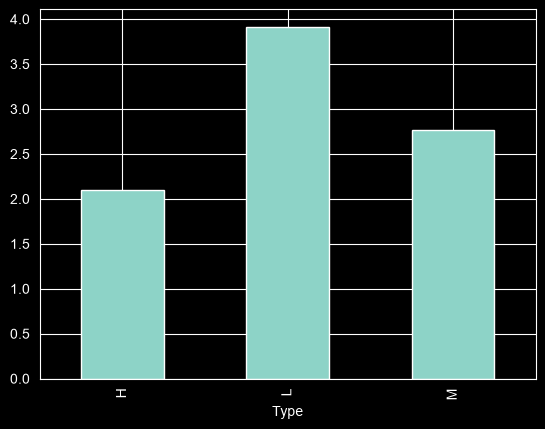

In [40]:
failure_rate = df.groupby("Type")["Machine failure"].mean() * 100
failure_rate.plot(kind="bar")


L having more machines is not the reason we're calling it higher risk

In [41]:
correlation_ = df.corr(numeric_only=True)
print(correlation_)

                         Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure
Air temperature [K]                 1.000000                 0.876107                0.022670    -0.013778         0.013853         0.082556
Process temperature [K]             0.876107                 1.000000                0.019277    -0.014061         0.013488         0.035946
Rotational speed [rpm]              0.022670                 0.019277                1.000000    -0.875027         0.000223        -0.044188
Torque [Nm]                        -0.013778                -0.014061               -0.875027     1.000000        -0.003093         0.191321
Tool wear [min]                     0.013853                 0.013488                0.000223    -0.003093         1.000000         0.105448
Machine failure                     0.082556                 0.035946               -0.044188     0.191321         0.105448         1.000000


1.High Air Temperature → higher observed failure rate
2.310–312 K Process Temperature → higher observed failure rate
3.Very high RPM → higher observed failure rate
4.Very high Torque → higher observed failure rate
5.Very high Tool Wear → substantially higher observed failure rate
6.L-type → highest observed failure rate

IOQ METHOD

1.Rototional Speed

In [42]:
Q1 = df["Rotational speed [rpm]"].quantile(0.25)
Q3 = df["Rotational speed [rpm]"].quantile(0.75)
IQR = Q3 - Q1
Lower_bound = Q1 - 1.5 * IQR
Upper_bound = Q3 + 1.5 * IQR
print("Lower:", Lower_bound)
print("Upper:", Upper_bound)

Lower: 1139.5
Upper: 1895.5


2.Torque

In [43]:
Q1 = df["Torque [Nm]"].quantile(0.25)
Q3 = df["Torque [Nm]"].quantile(0.75)
IQR = Q3 - Q1
Lower_bound = Q1 - 1.5 * IQR
Upper_bound = Q3 + 1.5 * IQR
print("Lower:", Lower_bound)
print("Upper:", Upper_bound)

Lower: 12.800000000000011
Upper: 67.19999999999999


Outlier analysis: IQR identified potential outliers in rotational speed and torque. These observations were retained because they may represent legitimate extreme operating conditions and could contain useful predictive information.
Outiler doesnt means that they are bad data

Feature Scaling

1:Temperature Difference

In [44]:
df["Temperature Difference"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Air Temp Bin,Process Temp Bin,Rotational speed Bin,Torque Bin,Tool wear bin,Temperature Difference
0,M,298.1,308.6,1551,42.8,0,0,"(297.14, 298.98]","(307.32, 308.94]","(1511.6, 1855.2]","(32.92, 47.48]","(-0.253, 50.6]",10.5
1,L,298.2,308.7,1408,46.3,3,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.5
2,L,298.1,308.5,1498,49.4,5,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(47.48, 62.04]","(-0.253, 50.6]",10.4
3,L,298.2,308.6,1433,39.5,7,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.4
4,L,298.2,308.7,1408,40.0,9,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.5


2.Mech Power

In [45]:
df["MechPower"] = (df["Torque [Nm]"] * df["Rotational speed [rpm]"]) / 9.549
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Air Temp Bin,Process Temp Bin,Rotational speed Bin,Torque Bin,Tool wear bin,Temperature Difference,MechPower
0,M,298.1,308.6,1551,42.8,0,0,"(297.14, 298.98]","(307.32, 308.94]","(1511.6, 1855.2]","(32.92, 47.48]","(-0.253, 50.6]",10.5,6951.806472
1,L,298.2,308.7,1408,46.3,3,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.5,6826.934758
2,L,298.1,308.5,1498,49.4,5,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(47.48, 62.04]","(-0.253, 50.6]",10.4,7749.628233
3,L,298.2,308.6,1433,39.5,7,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.4,5927.688763
4,L,298.2,308.7,1408,40.0,9,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.5,5897.999791


<Axes: xlabel='Mech_Power_binsa'>

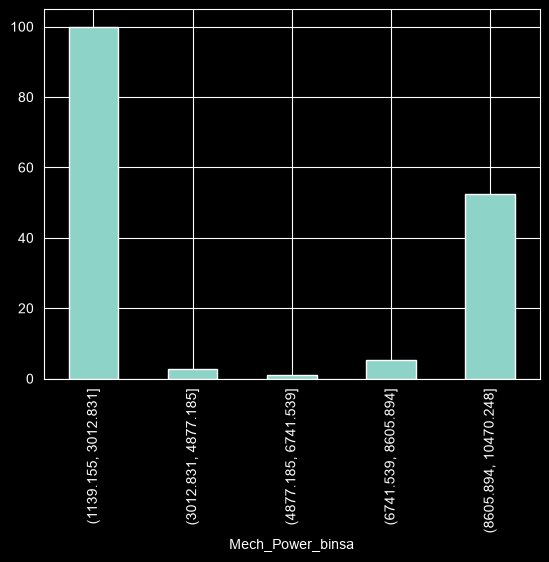

In [46]:
df["Mech_Power_binsa"] = pd.cut(
    df["MechPower"],
    bins=5
)
failure_rate = df.groupby("Mech_Power_binsa")["Machine failure"] .mean() * 100
failure_rate.plot(kind="bar")

Mechanical Power: Failure rates vary substantially across mechanical-power ranges, suggesting that mechanical power may provide useful predictive information. The relationship appears non-linear rather than strictly increasing or decreasing

<Axes: xlabel='Temp Difference Bin'>

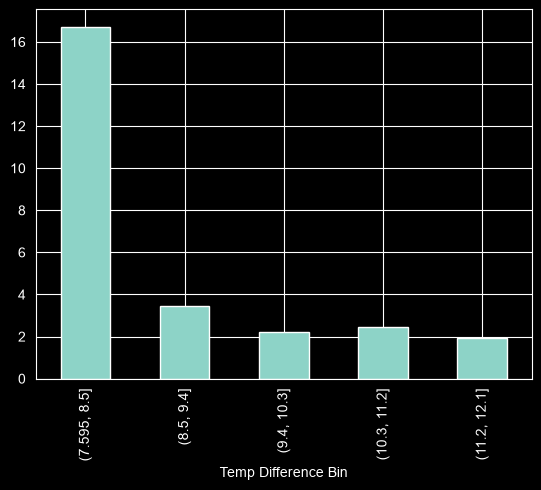

In [47]:
df["Temp Difference Bin"] = pd.cut(
    df["Temperature Difference"],
    bins = 5
)
failure_rate = df.groupby("Temp Difference Bin",observed = True)["Machine failure"] .mean() * 100
failure_rate.plot(kind="bar")

Temperature Difference: Lower temperature differences, particularly 7.95–8.5 K, show a substantially higher observed failure rate.

In [48]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Air Temp Bin,Process Temp Bin,Rotational speed Bin,Torque Bin,Tool wear bin,Temperature Difference,MechPower,Mech_Power_binsa,Temp Difference Bin
0,M,298.1,308.6,1551,42.8,0,0,"(297.14, 298.98]","(307.32, 308.94]","(1511.6, 1855.2]","(32.92, 47.48]","(-0.253, 50.6]",10.5,6951.806472,"(6741.539, 8605.894]","(10.3, 11.2]"
1,L,298.2,308.7,1408,46.3,3,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.5,6826.934758,"(6741.539, 8605.894]","(10.3, 11.2]"
2,L,298.1,308.5,1498,49.4,5,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(47.48, 62.04]","(-0.253, 50.6]",10.4,7749.628233,"(6741.539, 8605.894]","(10.3, 11.2]"
3,L,298.2,308.6,1433,39.5,7,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.4,5927.688763,"(4877.185, 6741.539]","(10.3, 11.2]"
4,L,298.2,308.7,1408,40.0,9,0,"(297.14, 298.98]","(307.32, 308.94]","(1166.282, 1511.6]","(32.92, 47.48]","(-0.253, 50.6]",10.5,5897.999791,"(4877.185, 6741.539]","(10.3, 11.2]"


- **Temperature Difference** = Process Temperature − Air Temperature
- **Mechanical Power** = Torque × RPM / 9.549
- Kept **Tool Wear** as a numerical feature since high wear showed higher failure rates.
- Analyzed the engineered features against machine failure.
- Temperature Difference showed higher failure rates at lower temperature differences.
- Mechanical Power showed a non-linear relationship with machine failure.
- Extreme RPM and Torque values were retained as they may represent important operating conditions.

In [49]:
X = df[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Temperature Difference",
        "MechPower"
    ]
]

y = df["Machine failure"]

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [51]:
print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [52]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference",
    "MechPower"
]

X = df[features]
y = df["Machine failure"]

In [53]:
import numpy as np

train_failure_pct = np.mean(y_train == 1) * 100
test_failure_pct = np.mean(y_test == 1) * 100

print(f"Train Failure Rate: {train_failure_pct:.2f}%")
print(f"Test Failure Rate: {test_failure_pct:.2f}%")

Train Failure Rate: 3.39%
Test Failure Rate: 3.40%


In [54]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference",
    "MechPower"
]

X = df[features]
y = df["Machine failure"]

 **Encoding the H L M

In [55]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[["Type"]])

X_test_encoded = encoder.transform(X_test[["Type"]])


encoder.get_feature_names_out(["Type"])

array(['Type_H', 'Type_L', 'Type_M'], dtype=object)

In [56]:
import pandas as pd


X_train_num = X_train.drop("Type", axis=1)
X_test_num = X_test.drop("Type", axis=1)


X_train_final = pd.concat(
    [X_train_num.reset_index(drop=True),
     pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(["Type"]))],
    axis=1
)

X_test_final = pd.concat(
    [X_test_num.reset_index(drop=True),
     pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(["Type"]))],
    axis=1
)

In [57]:
print(X_train_final.shape)
print(X_test_final.shape)

(8000, 10)
(2000, 10)


In [58]:
print(X_train_final.columns.tolist())
print(X_test_final.columns.tolist())

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference', 'MechPower', 'Type_H', 'Type_L', 'Type_M']
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference', 'MechPower', 'Type_H', 'Type_L', 'Type_M']


##BASELINE MODEL

In [59]:
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
logistics_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])
logistics_pipeline.fit(X_train_final, y_train)

prediction  = logistics_pipeline.predict(X_test_final)
print("Predicted Values:", prediction)


Predicted Values: [1 0 0 ... 0 0 0]


##Metrics

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, roc_curve
)
print("Accuracy:", accuracy_score(y_test, prediction) * 100)
print("Precision_score", precision_score(y_test, prediction) * 100)
print("Recall_score",recall_score(y_test, prediction) * 100)
print("F1_score", f1_score(y_test, prediction) * 100)
print("Confusion Matrix", confusion_matrix(y_test, prediction))


Accuracy: 96.75
Precision_score 57.14285714285714
Recall_score 17.647058823529413
F1_score 26.96629213483146
Confusion Matrix [[1923    9]
 [  56   12]]


The machine actually fails, but the model predicts that it won't.

Logistic Regression achieved 96.75% accuracy, but its recall was only 17.65%, indicating that the baseline model missed a large proportion of actual machine failures.

##XG BOOST

In [61]:
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
xgb_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', XGBClassifier(max_depth=3,random_state=42,n_estimators=100))
    ]
)
xgb_pipeline.fit(X_train_final, y_train)

prediction_xg = xgb_pipeline.predict(X_test_final)
print("Predicted Values:", prediction)

Predicted Values: [1 0 0 ... 0 0 0]


In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
print("Accuracy:", accuracy_score(y_test, prediction_xg) * 100)
print("Precision_score", precision_score(y_test, prediction_xg) * 100)
print("Recall_score", recall_score(y_test, prediction_xg) * 100)
print("F1_score", f1_score(y_test, prediction_xg) * 100)
print("ROC_AUC_score", roc_auc_score(y_test, prediction_xg) * 100)
print("Confusion Matrix", confusion_matrix(y_test, prediction_xg))

Accuracy: 98.85000000000001
Precision_score 89.47368421052632
Recall_score 75.0
F1_score 81.6
ROC_AUC_score 87.34472049689441
Confusion Matrix [[1926    6]
 [  17   51]]


XGBoost substantially outperformed Logistic Regression, particularly in identifying actual machine failures while maintaining high precision.

In [63]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

random_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier',RandomForestClassifier(max_depth=3,random_state=42,n_estimators=100,class_weight='balanced'))
])
random_pipeline.fit(X_train_final,y_train)
prediction_random = random_pipeline.predict(X_test_final)

In [64]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    f1_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
print("Accuracy:", accuracy_score(y_test, prediction_random) * 100)
print("Precision_score", precision_score(y_test, prediction_random) * 100)
print("Recall_score", recall_score(y_test, prediction_random) * 100)
print("F1_score", f1_score(y_test, prediction_random) * 100)
print("ROC_AUC_score", roc_auc_score(y_test, prediction_random) * 100)
print("Confusion Matrix", confusion_matrix(y_test, prediction_random))

Accuracy: 92.15
Precision_score 28.708133971291865
Recall_score 88.23529411764706
F1_score 43.32129963898917
ROC_AUC_score 90.26153939836804
Confusion Matrix [[1783  149]
 [   8   60]]


Random Forest's ROC-AUC (90.26%) is higher than XGBoost's (87.34%), despite its much worse precision/F1 at the current classification threshold.

##GRID SEARCH

In [70]:
from sklearn.model_selection import GridSearchCV

grid_search_xg = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid={
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [3, 4, 5],
        "classifier__learning_rate": [0.01, 0.1, 0.5],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0]
    },
    scoring="f1",
    cv=5,
    n_jobs=-1
)

(grid_search_xg.fit(X_train_final, y_train))

print(grid_search_xg.best_params_)
print(grid_search_xg.best_score_)
xgb_pred_grid = grid_search_xg.predict(X_test_final)

{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
0.8175390340209272


In [69]:
from sklearn.metrics import(
accuracy_score,
precision_score,
f1_score,
recall_score,
roc_auc_score,
)
print("Accuracy:", accuracy_score(y_test, xgb_pred_grid) * 100)
print("Precision_score", precision_score(y_test, xgb_pred_grid) * 100)
print("Recall_score", recall_score(y_test, xgb_pred_grid) * 100)
print("F1_score", f1_score(y_test, xgb_pred_grid) * 100)
print("ROC_AUC_score", roc_auc_score(y_test, xgb_pred_grid) * 100)
print("Confusion Matrix", confusion_matrix(y_test, xgb_pred_grid))


Accuracy: 99.1
Precision_score 93.10344827586206
Recall_score 79.41176470588235
F1_score 85.71428571428571
ROC_AUC_score 89.60236268420411
Confusion Matrix [[1928    4]
 [  14   54]]


#THRESHOLD

In [75]:
import numpy as np
from sklearn.metrics import f1_score

# Predicted probabilities
xgb_prob = grid_search_xg.predict_proba(X_test_final)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    y_pred_threshold = (xgb_prob >= threshold).astype(int)

    f1 = f1_score(y_test, y_pred_threshold)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold * 100)
print("Best F1 Score:", best_f1 * 100)

Best Threshold: 33.999999999999986
Best F1 Score: 86.36363636363636


Optimized XGBoost threshold: 0.34, achieving an F1 score of 86.36%.

In [80]:
from sklearn.metrics import recall_score

best_threshold = 0
best_recall = 0

for threshold in thresholds:
    y_pred_threshold = (xgb_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_pred_threshold)

    if recall > best_recall:
        best_recall = recall
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Recall:", best_recall * 100)

Best Threshold: 0.1
Best Recall: 85.29411764705883


In [82]:
from sklearn.metrics import precision_score

best_threshold = 0
best_precision = 0

for threshold in thresholds:
    y_pred_threshold = (xgb_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)

    if precision > best_precision:
        best_precision = precision
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Precision:", best_precision * 100)

Best Threshold: 0.8899999999999996
Best Precision: 100.0


In [83]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

xgb_prob = grid_search_xg.predict_proba(X_test_final)[:, 1]
thresholds = np.arange(0.05, 0.91, 0.05)

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
for t in thresholds:
    preds = (xgb_prob >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    print(f"{t:10.2f} {p:10.3f} {r:10.3f} {f:10.3f}")

 Threshold  Precision     Recall         F1
      0.05      0.517      0.897      0.656
      0.10      0.617      0.853      0.716
      0.15      0.734      0.853      0.789
      0.20      0.806      0.853      0.829
      0.25      0.817      0.853      0.835
      0.30      0.864      0.838      0.851
      0.35      0.891      0.838      0.864
      0.40      0.902      0.809      0.853
      0.45      0.931      0.794      0.857
      0.50      0.931      0.794      0.857
      0.55      0.927      0.750      0.829
      0.60      0.923      0.706      0.800
      0.65      0.922      0.691      0.790
      0.70      0.940      0.691      0.797
      0.75      0.936      0.647      0.765
      0.80      0.953      0.603      0.739
      0.85      0.975      0.574      0.722
      0.90      1.000      0.515      0.680


I chose threshold 0.25 because recall saturates at 85.3% below this point — lowering the threshold further only hurts precision with no recall benefit. This catches 85% of actual failures while keeping false alarms manageable (82% precision), which is more appropriate than the default 0.5 threshold or a pure F1-optimal choice, given that missed failures are costlier than false positives in a maintenance context

In [84]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42,
)

In [85]:
from sklearn.model_selection import cross_val_predict

oof_prob = cross_val_predict(
    grid_search_xg.best_estimator_,
    X_train_final,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [87]:
thresholds = np.arange(0.05, 0.91, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    oof_pred = (oof_prob >= threshold).astype(int)

    f1 = f1_score(y_train, oof_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("CV Best Threshold:", best_threshold * 100)
print("CV Best F1:", best_f1 * 100)

CV Best Threshold: 30.000000000000004
CV Best F1: 81.34328358208955


In [101]:
final_threshold = 0.30
xgb_prob_test = grid_search_xg.predict_proba(X_test_final)[:, 1]
y_pred_final = (xgb_prob_test >= final_threshold).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("Precision:", precision_score(y_test, y_pred_final )* 100)
print("Recall:", recall_score(y_test, y_pred_final )* 100)
print("F1:", f1_score(y_test, y_pred_final) * 100)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

Precision: 86.36363636363636
Recall: 83.82352941176471
F1: 85.07462686567165
Confusion Matrix:
 [[1923    9]
 [  11   57]]


In [112]:
import joblib
final_model = grid_search_xg.best_estimator_
final_threshold = 0.30

joblib.dump(final_model, 'xgb_final_model.pkl')
joblib.dump(final_threshold, 'xgb_final_threshold.pkl')
joblib.dump(list(X_train_final.columns), 'feature_names.pkl')
print("Model saved")
print("Threshold:", final_threshold)

Model saved
Threshold: 0.3


In [110]:
model = joblib.load("xgb_final_model.pkl")
threshold = joblib.load("xgb_final_threshold.pkl")
